In [357]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.special import factorial 
from scipy import stats
import pandas as pd

import util


plt.rc('text', usetex=True)
plt.rc('font', family='serif')

plt.figure(figsize=(10,6), dpi=300)

<Figure size 3000x1800 with 0 Axes>

<Figure size 3000x1800 with 0 Axes>

In [358]:
# Draw samples from a poissonian distribution
# use pandas to open pendulumData (1).csv
df = pd.read_csv("pendulumData (1).csv")
cutoff = 10

#print columns
print(df.columns)
# need explanation 
def iqr(data):
    q75, q25 = np.percentile(data, [75 ,25])
    iqr = q75 - q25
    return iqr

iqr_val = iqr(df['g (m/s2)'])

median  = df['g (m/s2)'].median()

pendulum_data = df[np.abs(df['g (m/s2)'] - median) <= iqr_val*cutoff]
pendulum_data_outliers = df[np.abs(df['g (m/s2)'] - median) >= iqr_val*cutoff]

print(pendulum_data_outliers)
counts = pendulum_data[r'g (m/s2)']

# get statistics
mean = counts.mean()
std = counts.std()
err = std/np.sqrt(len(counts))
print(f"Mean: {mean:.2f}")
print(f"Standard Deviation: {std:.2f}")
print(f"Standard error: {err :.2f}")




Index(['label', 'g (m/s2)', 'stat uncert', 'sys uncert', 'total uncert'], dtype='str')
               label  g (m/s2) stat uncert sys uncert total uncert
4    20.Sep.X.B01.05    978.00          17          8          NaN
50   21.Sep.A.B02.08     12.22        1.29       1.22          NaN
68   21.Sep.A.B04.03     14.60         NaN        NaN          5.3
89   21.Sep.B.B02.07     12.22        1.29       1.22          NaN
226  23.Feb.A.B02.02     15.70         NaN        NaN          3.9
270  23.Sep.A.B02.09      6.95         NaN        NaN         1.07
347  24.Feb.A.B01.04     14.64         NaN        NaN         3.82
370  24.Sep.A.B01.09     12.83         NaN        NaN         1.74
390  24.Sep.A.B03.09     12.40         NaN        NaN          0.3
404  24.Sep.A.B04.11     12.82         NaN        NaN         0.13
466   25.Feb.A.B02.9      0.60         0.1       0.09         0.19
503   25.Sep.A.B03.1     13.00           2        NaN          NaN
510   25.Sep.A.B03.8     13.22         NaN

In [359]:

# Perform fit of histogram to double gaussian
freqs, bins = np.histogram(counts, bins=50)
#normalize frequencies by bin width and total number of counts
normalization = (bins[1] - bins[0]) * len(counts)
sig = np.sqrt(freqs) / normalization # Poissonian uncertainty
freqs = freqs / normalization
bin_centers = 0.5 * (bins[1:] + bins[:-1])


bin_centers, freqs, sig = util.delete_zeros(bin_centers, freqs,sig) # Take out the zeros from our data
popt, pcov = opt.curve_fit(f=util.two_gaussian, xdata=bin_centers, ydata=freqs, sigma=sig, p0=[9, 13, 0.1, 9, 3, 2], absolute_sigma=True) # Fit function
uncert = np.sqrt(np.diag(pcov)) # Extract uncertainty from fit
print(popt)
print(uncert)

[9.80713125 0.18776966 0.06706974 9.79977057 0.18859284 0.48788495]
[0.00515029 0.01443555 0.00513843 0.03164654 0.01440543 0.03067895]


35.60507636208737


<>:37: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:40: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:37: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:40: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_9080/3328124353.py:37: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.axvline(weighted_mean, color='red', linestyle='--', label=f'$\mu$: {mean:.2f} m/s$^2$')
/tmp/ipykernel_9080/3328124353.py:40: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences w

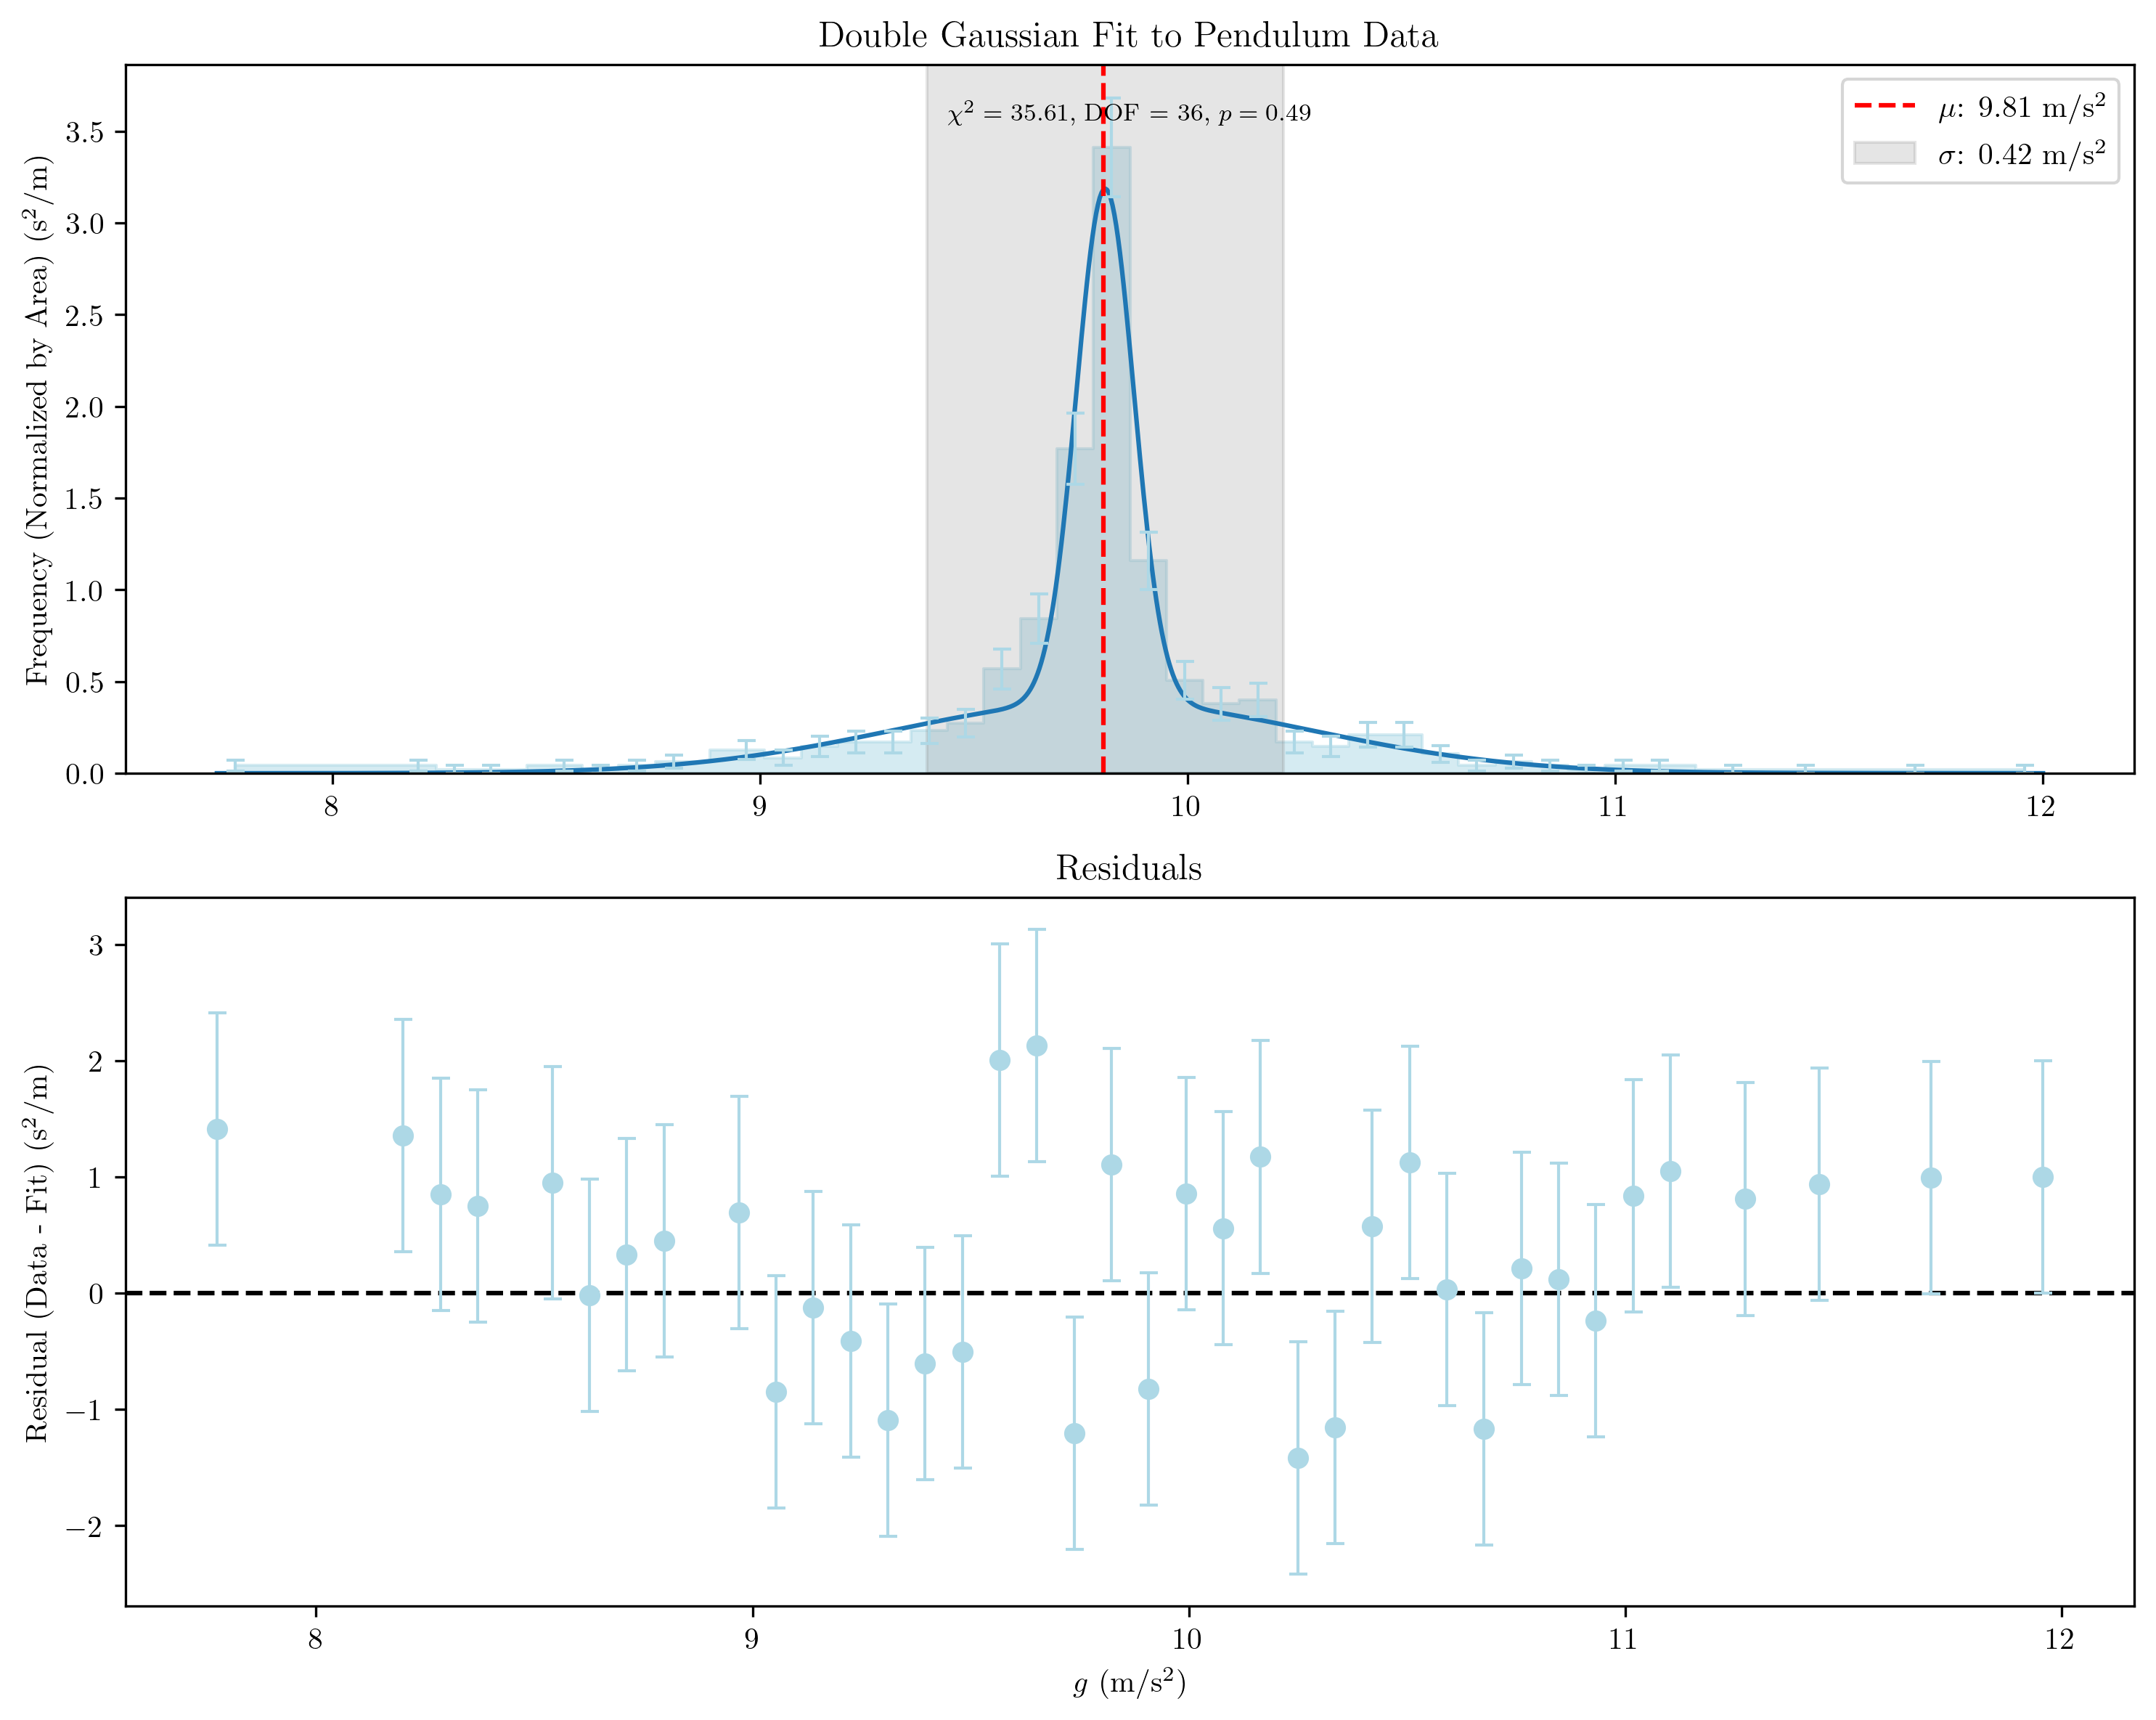

In [360]:

mean = counts.mean()
std = counts.std()
err = std/np.sqrt(len(counts))

mean_1, amp_1, std_1 = popt[0], popt[1], popt[2]
mean_2, amp_2, std_2 = popt[3], popt[4], popt[5]

amp = amp_1 + amp_2
weight_1 = amp_1 / amp
weight_2 = amp_2 / amp

weighted_mean = mean_1 * weight_1 + mean_2 * weight_2

x = np.linspace(start=np.min(counts), stop=np.max(counts), num=1000, endpoint=True)  # Define x for smoother plotting of our poisson fit function

# Plot chi2
chi2 = util.chisq(util.two_gaussian, popt, bin_centers, freqs, sig)
print(chi2)
dof = len(bin_centers) - 2
chi2_probs = 1 - stats.chi2.cdf(chi2, dof)  # Get the probability by subtracting 1 from the cumulative distribution function

# Create subplots
plt.figure(figsize=(10, 8), dpi=300)

plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st subplot
plt.fill_between(bin_centers, freqs, step='mid', color='lightblue', alpha=0.5)  # Fill area underneath the step plot
plt.plot(x, util.two_gaussian(x, *popt))  # Plot fit function
plt.errorbar(bin_centers, freqs, yerr=sig, linewidth=1, ls='none', fmt='', capsize=3, color='lightblue')  # Plot actual data

# Add text annotations to the plot with the chi2 value, dof, and chi2 probability
plt.text(0.5, 0.95, r'$\chi^2 = {:.2f}$, DOF = {}, $p = {:.2f}$'.format(chi2, dof, chi2_probs),
         transform=plt.gca().transAxes, ha='center', va='top', fontsize=8)

# Label the x and y axes with units
plt.ylabel(r'Frequency (Normalized by Area) (s$^2$/m)')
plt.title('Double Gaussian Fit to Pendulum Data')
plt.axvline(weighted_mean, color='red', linestyle='--', label=f'$\mu$: {mean:.2f} m/s$^2$')

#fill between mean - stderr and mean + stderr
plt.axvspan(mean - std, mean + std, color='gray', alpha=0.2, label=f'$\sigma$: {std:.2f} m/s$^2$')
plt.legend()
plt.ylim(bottom=0)


## Residuals Plot
plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd subplot
plt.axhline(0, color='black', linestyle='--')

residuals = (freqs - util.two_gaussian(bin_centers, *popt))/sig
plt.plot(bin_centers, residuals, marker='o', linestyle='none', color='lightblue')
plt.errorbar(bin_centers, residuals, yerr=sig/sig, linewidth=1, ls='none', fmt='', capsize=3, color='lightblue')

plt.xlabel(r'$g$ (m/s$^2$)')
plt.ylabel('Residual (Data - Fit) (s$^2$/m)')
plt.title('Residuals')
### End residuas plot

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


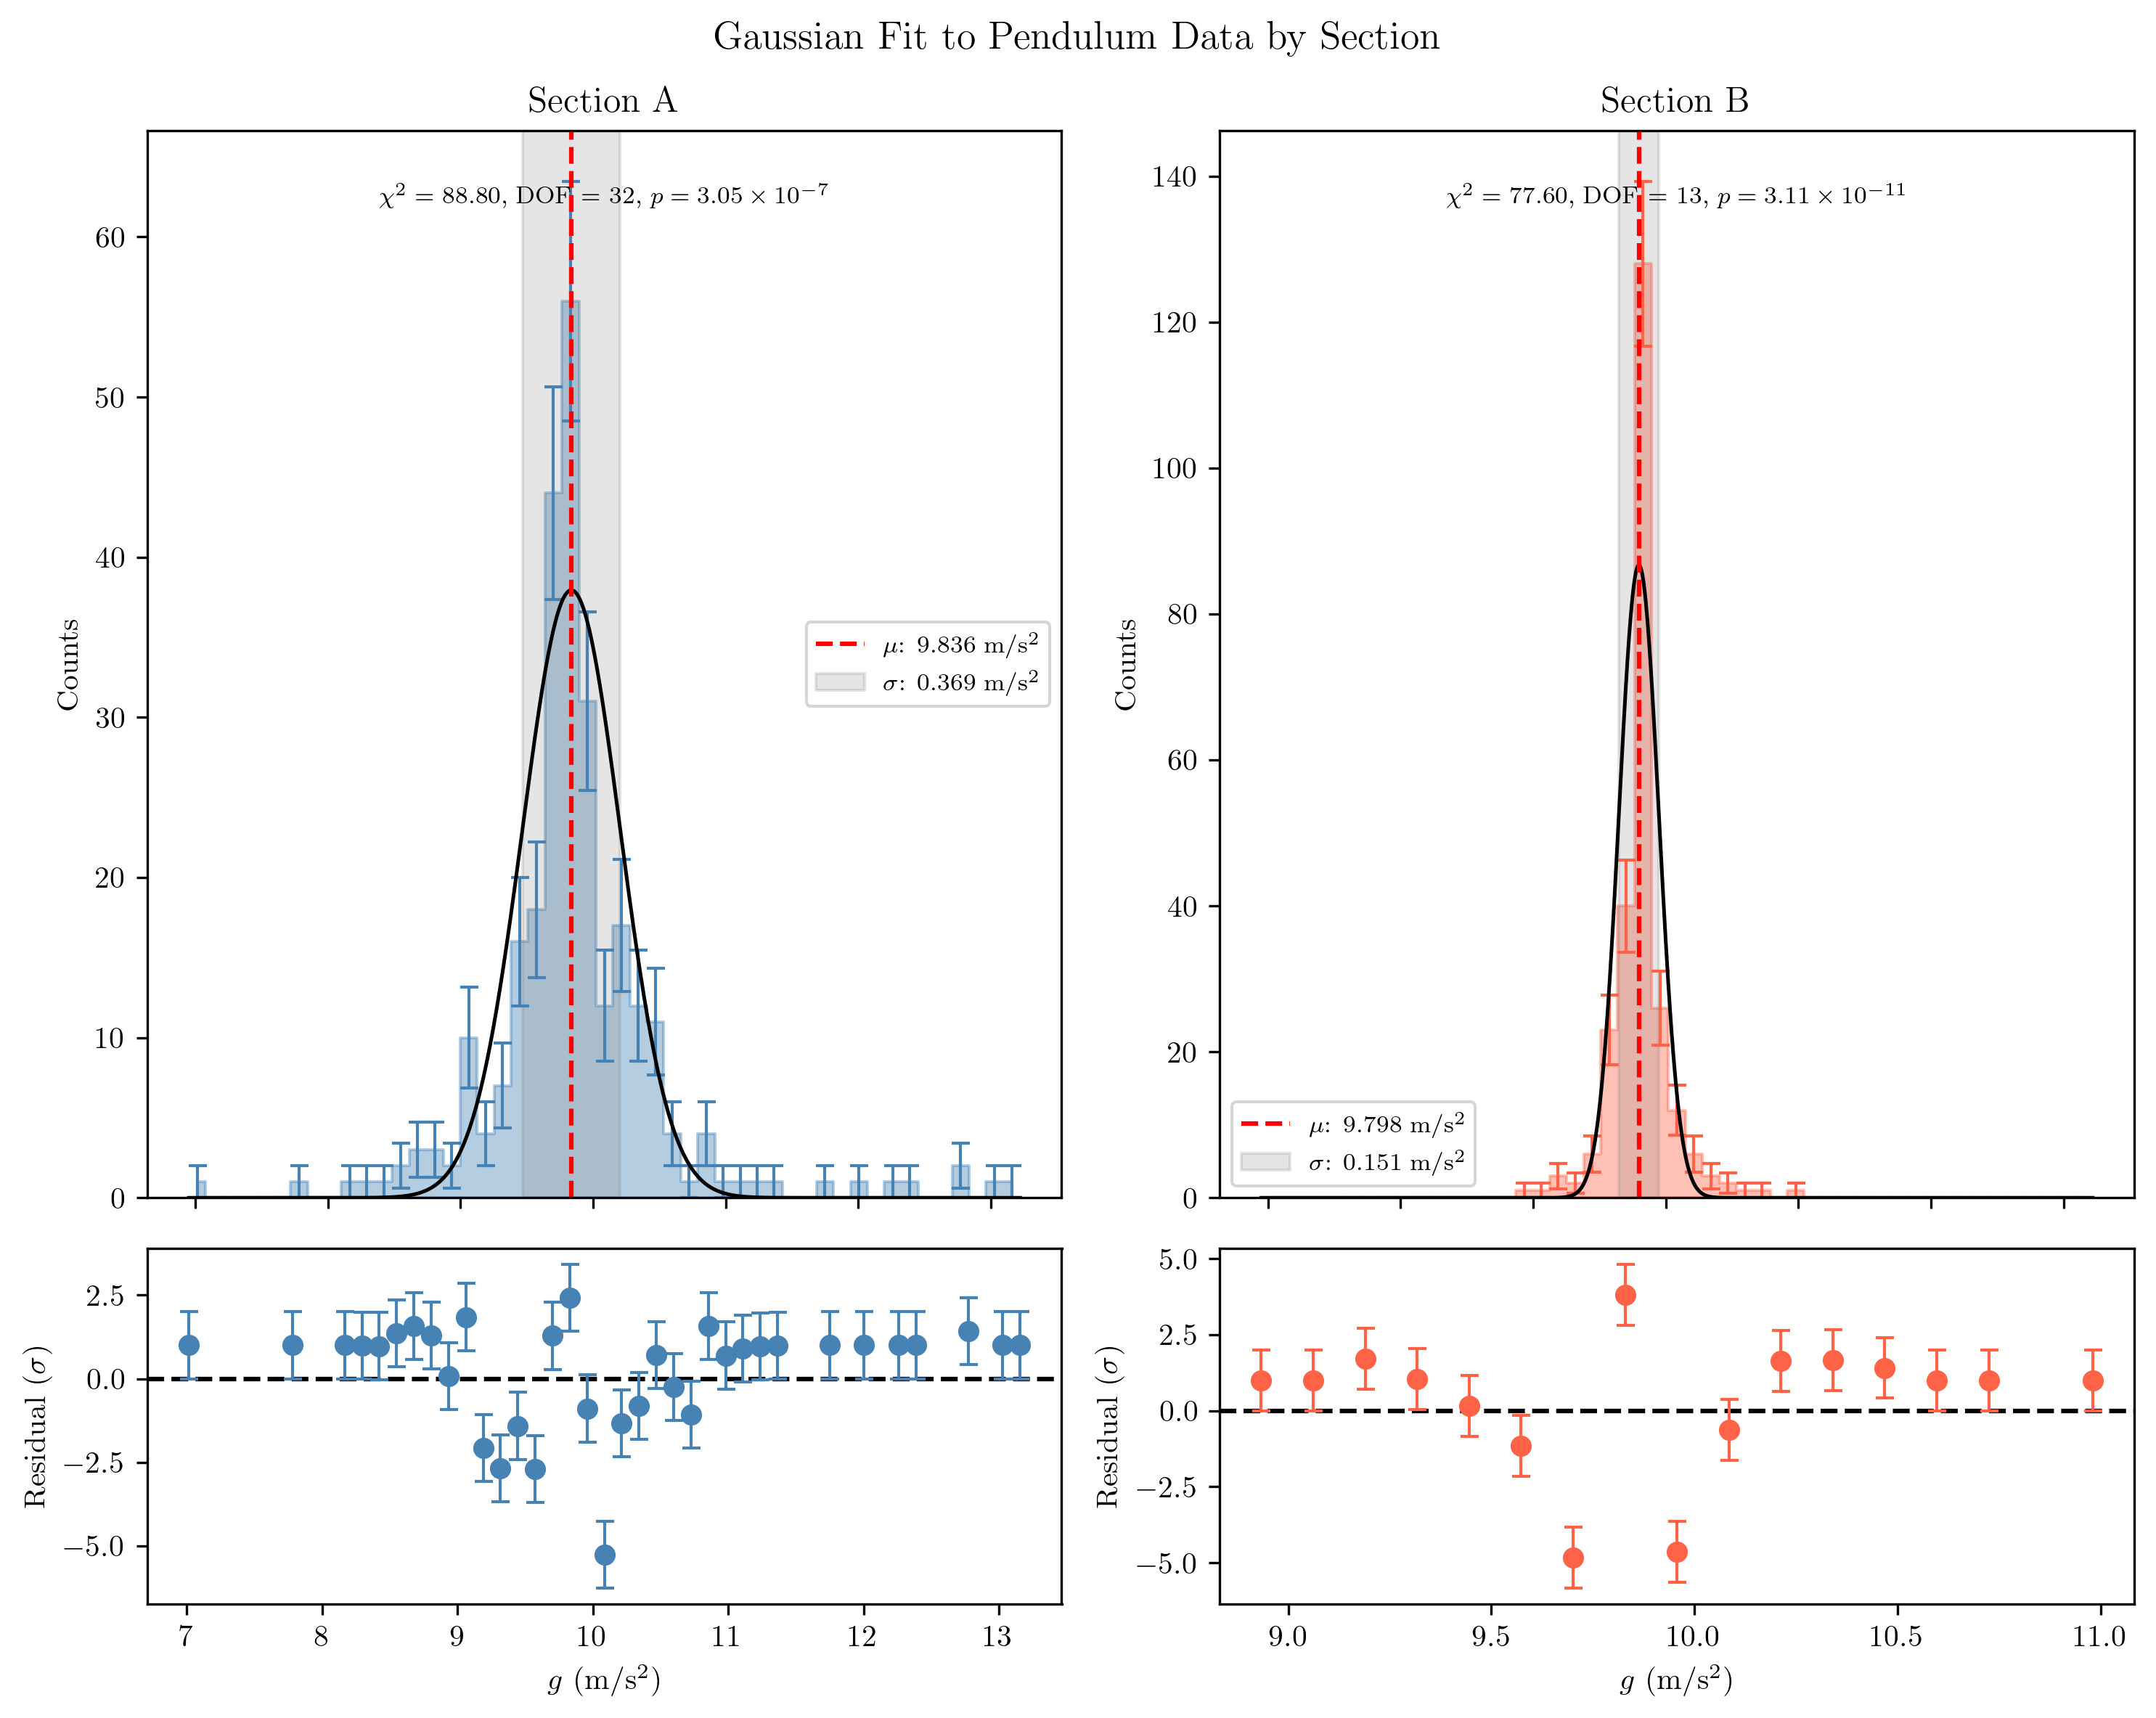

In [361]:

nbins =50
# Split data by A/B section label (3rd dot-separated field after the year)
# e.g. "21.Sep.A.B01.01" -> parts[2] == "A"
def get_section(label):
    parts = label.split('.')
    if len(parts) >= 3 and parts[2] in ('A', 'B'):
        return parts[2]
    return None

df['section'] = df['label'].apply(get_section)

data_A_raw = df[df['section'] == 'A']['g (m/s2)']
data_B_raw = df[df['section'] == 'B']['g (m/s2)']

# Apply same IQR-based outlier removal per group
def filter_outliers(data, cutoff=10):
    median = data.median()
    iqr_val = iqr(data)
    return data[np.abs(data - median) <= iqr_val * cutoff]

data_A = filter_outliers(data_A_raw)
data_B = filter_outliers(data_B_raw)

# Shared bins spanning the full range of both datasets
combined_min = min(data_A.min(), data_B.min())
combined_max = max(data_A.max(), data_B.max())
shared_bins = np.linspace(combined_min, combined_max, nbins)

def p_latex(p):
    coef, exp = '{:.2e}'.format(p).split('e')
    return r'$p = {} \times 10^{{{}}}$'.format(coef, int(exp))

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300,
                         gridspec_kw={'height_ratios': [3, 1]})

for col, (data, section, color) in enumerate(zip([data_A, data_B], ['A', 'B'], ['steelblue', 'tomato'])):
    ax_hist = axes[0, col]
    ax_res  = axes[1, col]

    # Build normalized histogram with shared bins
    freqs, bin_edges = np.histogram(data, bins=shared_bins)
    normalization = (bin_edges[1] - bin_edges[0]) * len(data)
    sig = np.sqrt(freqs) / normalization   # uncertainty in density space
    freqs_norm = freqs / normalization     # density space (used for fitting)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    # Remove zero bins for fitting
    bc, fn, sn = util.delete_zeros(bin_centers, freqs_norm, sig)

    # Fit single Gaussian, then force amplitude to 1 (normalized PDF)
    popt, pcov = opt.curve_fit(util.gaussian, bc, fn, sigma=sn,
                               p0=[data.mean(), 1, data.std()], absolute_sigma=True)
    popt[1] = 1.0
    mu, _, std = popt

    # Chi-squared statistics (computed in density space before forcing A=1)
    chi2 = util.chisq(util.gaussian, popt, bc, fn, sn)
    dof = len(bc) - 3
    p_val = 1 - stats.chi2.cdf(chi2, dof)

    x = np.linspace(combined_min, combined_max, 1000)

    # --- Histogram + fit (plotted in counts space) ---
    ax_hist.fill_between(bin_centers, freqs_norm * normalization, step='mid', color=color, alpha=0.4)
    ax_hist.errorbar(bin_centers, freqs_norm * normalization, yerr=sig * normalization,
                     linewidth=1, ls='none', fmt='', capsize=3, color=color)
    ax_hist.plot(x, util.gaussian(x, *popt) * normalization, color='black', linewidth=1.2)

    ax_hist.text(0.5, 0.95, r'$\chi^2 = {:.2f}$, DOF = {}, '.format(chi2, dof) + p_latex(p_val),
                 transform=ax_hist.transAxes, ha='center', va='top', fontsize=8)
    ax_hist.axvline(mu, color='red', linestyle='--', label=r'$\mu$: {:.3f} m/s$^2$'.format(mu))
    ax_hist.axvspan(mu - std, mu + std, color='gray', alpha=0.2, label=r'$\sigma$: {:.3f} m/s$^2$'.format(std))
    ax_hist.set_title(f'Section {section}', fontsize=12)
    ax_hist.set_ylabel('Counts')
    ax_hist.legend(fontsize=8)
    ax_hist.set_ylim(bottom=0)
    ax_hist.set_xticklabels([])

    # --- Residuals (in density space, as in single_fit.ipynb) ---
    residuals = (fn - util.gaussian(bc, *popt)) / sn
    ax_res.axhline(0, color='black', linestyle='--')
    ax_res.plot(bc, residuals, marker='o', linestyle='none', color=color)
    ax_res.errorbar(bc, residuals, yerr=np.ones_like(residuals), linewidth=1, ls='none', fmt='', capsize=3, color=color)
    ax_res.set_xlabel(r'$g$ (m/s$^2$)')
    ax_res.set_ylabel(r'Residual ($\sigma$)')

plt.suptitle('Gaussian Fit to Pendulum Data by Section', fontsize=13)
plt.tight_layout()
plt.show()


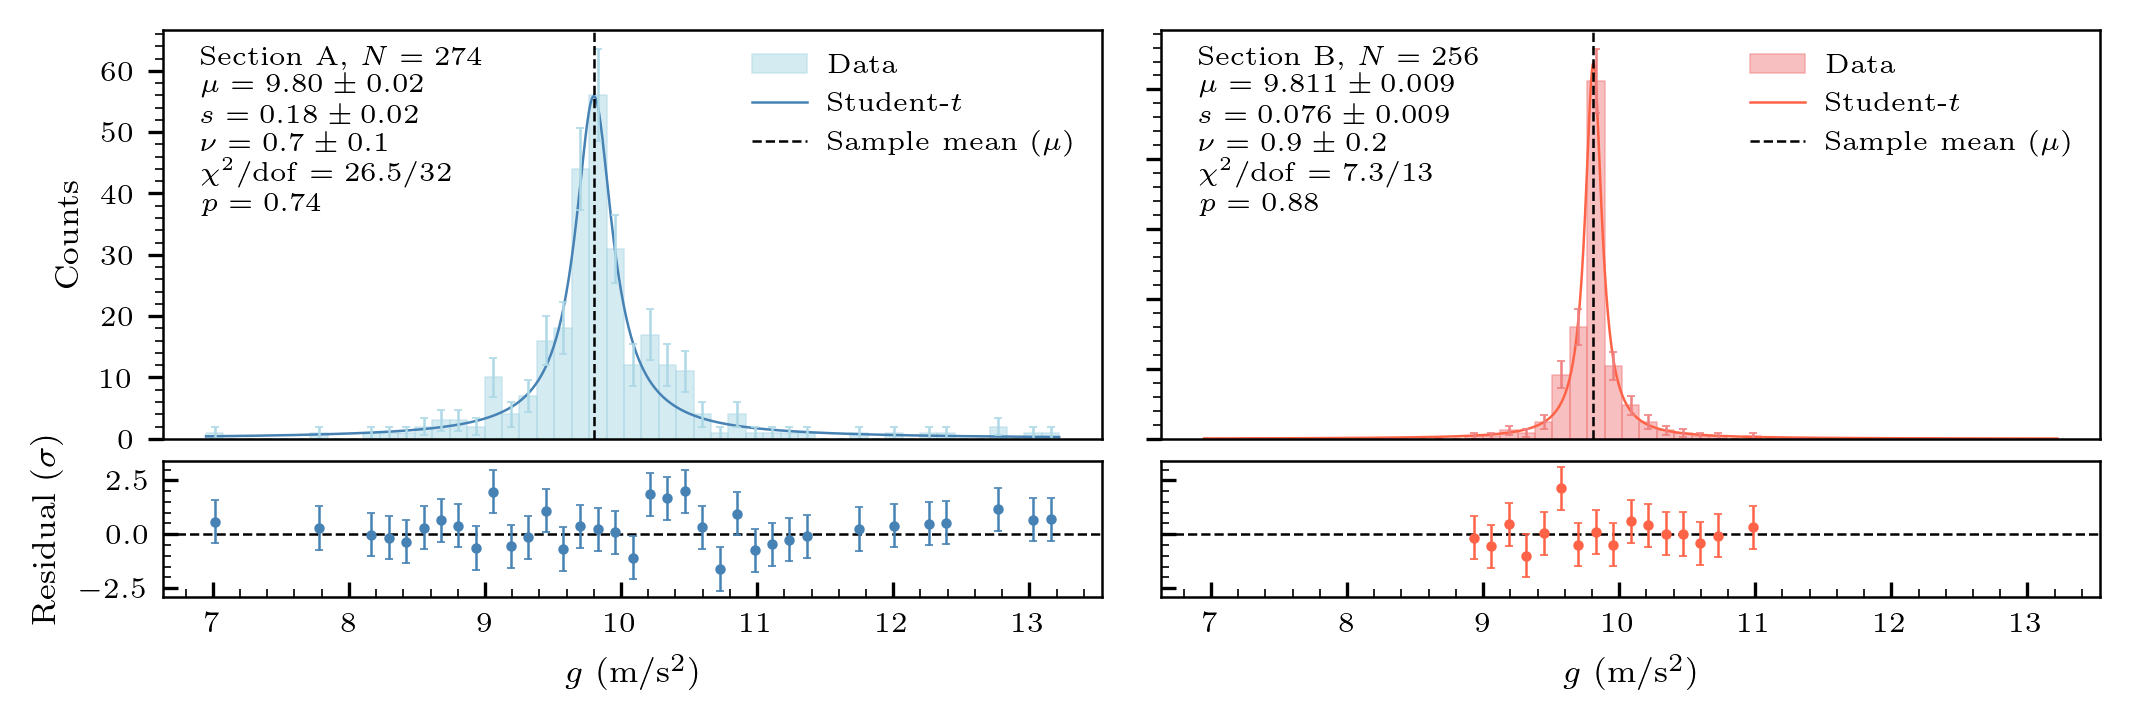

In [362]:

import matplotlib.ticker as ticker
from scipy.stats import t as t_rv
from scipy.integrate import quad

def student_t_pdf(x, mu, s, nu):
    return t_rv.pdf(x, nu, loc=mu, scale=s)

def fmt_param(val, err):
    """Format 'val ± err' rounded to the first nonzero decimal place of err."""
    if not np.isfinite(err) or err == 0:
        return r'{:.4f} \pm {:.4f}'.format(val, err)
    n = max(0, -int(np.floor(np.log10(abs(err)))))
    return (r'{{:.{0}f}} \pm {{:.{0}f}}'.format(n)).format(val, err)

# Style constants (matching single_fit.ipynb)
capsize  = 1
capthick = 0.4
lw       = 0.6
hist_lw  = 0.4
span_lw  = 0.4
ms       = 1.5
spine_lw = 0.6

section_styles = {
    'A': {'data_color': 'lightblue',  'accent': 'steelblue'},
    'B': {'data_color': 'lightcoral', 'accent': 'tomato'},
}

def plot_histogram(ax, bin_centers, freqs, normalization, bin_edges, **kwargs):
    bw = bin_edges[1] - bin_edges[0]
    x_fill = np.array([[c - bw/2, c + bw/2, np.nan] for c in bin_centers]).ravel()
    y_fill = np.array([[f, f, np.nan] for f in freqs * normalization]).ravel()
    ax.fill_between(x_fill, y_fill, **kwargs)

fig, axes = plt.subplots(2, 2, figsize=(7.2, 2.5), dpi=300, sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

for col, section in enumerate(['A', 'B']):
    ax_hist = axes[0, col]
    ax_res  = axes[1, col]
    style = section_styles[section]
    data = data_A if section == 'A' else data_B

    freqs, bin_edges = np.histogram(data, bins=shared_bins)
    normalization = (bin_edges[1] - bin_edges[0]) * len(data)
    sig = np.sqrt(freqs) / normalization
    freqs_norm = freqs / normalization
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    bc, fn, sn = util.delete_zeros(bin_centers, freqs_norm, sig)

    popt, pcov = opt.curve_fit(student_t_pdf, bc, fn, sigma=sn,
                               p0=[data.mean(), data.std() * 0.6, 5.0],
                               bounds=([-np.inf, 1e-6, 0.5], [np.inf, np.inf, np.inf]),
                               absolute_sigma=True, maxfev=10000)
    uncert = np.sqrt(np.diag(pcov))
    mu, s, nu = popt
    mu_err, s_err, nu_err = uncert

    chi2_val = util.chisq(student_t_pdf, popt, bc, fn, sn)
    dof_stat = len(bc) - 3
    p_val = 1 - stats.chi2.cdf(chi2_val, dof_stat)

    x = np.linspace(combined_min, combined_max, 1000)

    plot_histogram(ax_hist, bc, fn, normalization, bin_edges,
                   color=style['data_color'], alpha=0.5, linewidth=hist_lw, label='Data')
    ax_hist.plot(x, student_t_pdf(x, *popt) * normalization,
                 linewidth=lw, color=style['accent'], label='Student-$t$')
    ax_hist.errorbar(bin_centers, freqs_norm * normalization, yerr=sig * normalization,
                     linewidth=lw, ls='none', fmt='', capsize=capsize, capthick=capthick,
                     color=style['data_color'])
    ax_hist.axvline(mu, color='black', linestyle='--', linewidth=lw,
                    label=r'Sample mean ($\mu$)')

    stats_text = '\n'.join([
        f'Section {section},  $N={len(data)}$',
        r'$\mu = {}$'.format(fmt_param(mu, mu_err)),
        r'$s = {}$'.format(fmt_param(s, s_err)),
        r'$\nu = {}$'.format(fmt_param(nu, nu_err)),
        r'$\chi^2$/dof $= {:.1f}/{}$'.format(chi2_val, dof_stat),
        r'$p = {:.2f}$'.format(p_val),
    ])
    ax_hist.text(0.04, 0.96, stats_text, transform=ax_hist.transAxes,
                 ha='left', va='top', fontsize=6.5)

    leg = ax_hist.legend(frameon=False, fontsize=6.5, loc='upper right')
    for text in leg.get_texts():
        text.set_ha('right')
    ax_hist.set_ylim(bottom=0)
    ax_hist.tick_params(axis='x', which='both', length=0)
    ax_hist.tick_params(axis='y', labelsize=7, direction='out', which='major')
    ax_hist.tick_params(axis='y', direction='out', which='minor', length=2, width=0.4)
    ax_hist.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    for spine in ax_hist.spines.values():
        spine.set_linewidth(spine_lw)

    residuals = (fn - student_t_pdf(bc, *popt)) / sn
    ax_res.axhline(0, color='black', linestyle='--', linewidth=lw)
    ax_res.plot(bc, residuals, marker='o', markersize=ms, linestyle='none', color=style['accent'])
    ax_res.errorbar(bc, residuals, yerr=np.ones_like(residuals),
                    linewidth=lw, ls='none', fmt='', capsize=capsize, capthick=capthick,
                    color=style['accent'])
    ax_res.set_xlabel(r'$g$ (m/s$^2$)', fontsize=8)
    ax_res.tick_params(labelsize=7, direction='in', which='major')
    ax_res.tick_params(direction='in', which='minor', length=2, width=0.4)
    ax_res.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax_res.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    for spine in ax_res.spines.values():
        spine.set_linewidth(spine_lw)

# Y-axis labels on left column only
axes[0, 0].set_ylabel('Counts', fontsize=8)
axes[1, 0].set_ylabel(r'Residual ($\sigma$)', fontsize=8)

# Suppress right-column y tick labels on main plots
axes[0, 1].tick_params(labelleft=False)

# Share y-axis for residuals and suppress right-column tick labels
axes[1, 1].sharey(axes[1, 0])
axes[1, 1].tick_params(labelleft=False)

plt.tight_layout()
fig.subplots_adjust(hspace=0.08)
plt.savefig('pendulum_double_fit.png', dpi=300)
plt.show()


In [363]:

# Weighted mean of the two Student-t fit results
# Re-run fits to extract mu and sigma_mu for each section
results = {}
for section, data in [('A', data_A), ('B', data_B)]:
    freqs, bin_edges = np.histogram(data, bins=shared_bins)
    normalization = (bin_edges[1] - bin_edges[0]) * len(data)
    sig = np.sqrt(freqs) / normalization
    freqs_norm = freqs / normalization
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    bc, fn, sn = util.delete_zeros(bin_centers, freqs_norm, sig)

    popt, pcov = opt.curve_fit(student_t_pdf, bc, fn, sigma=sn,
                               p0=[data.mean(), data.std() * 0.6, 5.0],
                               bounds=([-np.inf, 1e-6, 0.5], [np.inf, np.inf, np.inf]),
                               absolute_sigma=True, maxfev=10000)
    results[section] = {'mu': popt[0], 'sigma_mu': np.sqrt(pcov[0, 0])}

mu_A,  sigma_A = results['A']['mu'], results['A']['sigma_mu']
mu_B,  sigma_B = results['B']['mu'], results['B']['sigma_mu']

# --- Consistency check ---
Z = abs(mu_A - mu_B) / np.sqrt(sigma_A**2 + sigma_B**2)

# --- Weighted mean ---
w_A = 1 / sigma_A**2
w_B = 1 / sigma_B**2
mu_combined    = (w_A * mu_A + w_B * mu_B) / (w_A + w_B)
sigma_combined = 1 / np.sqrt(w_A + w_B)

# --- Comparison to accepted value ---
g_accepted = 9.80665  # m/s², BIPM standard gravity
discrepancy = mu_combined - g_accepted
pull = discrepancy / sigma_combined

print("Individual fit results:")
print(f"  Section A:  mu = {mu_A:.5f} ± {sigma_A:.5f} m/s²")
print(f"  Section B:  mu = {mu_B:.5f} ± {sigma_B:.5f} m/s²")
print()
print("Consistency check:")
print(f"  Z = |mu_A - mu_B| / sqrt(sigma_A² + sigma_B²) = {Z:.3f}")
print(f"  {'Consistent (|Z| < 2)' if Z < 2 else 'INCONSISTENT (|Z| >= 2) — consider Birge scaling'}")
print()
print("Weighted mean:")
print(f"  g = {mu_combined:.5f} ± {sigma_combined:.5f} m/s²")
print()
print("Comparison to accepted value:")
print(f"  g_accepted  = {g_accepted:.5f} m/s²  (BIPM standard gravity)")
print(f"  Difference  = {discrepancy:+.5f} m/s²  ({discrepancy/g_accepted*100:+.4f}%)")
print(f"  Pull        = (g_combined - g_accepted) / sigma = {pull:+.2f} sigma")
print(f"  {'Compatible with accepted value (|pull| < 2)' if abs(pull) < 2 else 'DISCREPANT from accepted value (|pull| >= 2)'}")


Individual fit results:
  Section A:  mu = 9.80024 ± 0.01659 m/s²
  Section B:  mu = 9.81080 ± 0.00906 m/s²

Consistency check:
  Z = |mu_A - mu_B| / sqrt(sigma_A² + sigma_B²) = 0.558
  Consistent (|Z| < 2)

Weighted mean:
  g = 9.80837 ± 0.00795 m/s²

Comparison to accepted value:
  g_accepted  = 9.80665 m/s²  (BIPM standard gravity)
  Difference  = +0.00172 m/s²  (+0.0175%)
  Pull        = (g_combined - g_accepted) / sigma = +0.22 sigma
  Compatible with accepted value (|pull| < 2)
